In [1]:
# ============================================
# Notebook 05
# Task Dashboard
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from datetime import datetime

plt.style.use("ggplot")

plt.rcParams["figure.figsize"]=(10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

data_folder = os.path.join(project_folder,"data")

reports_folder = os.path.join(project_folder,"reports")

charts_folder = os.path.join(project_folder,"charts")

os.makedirs(reports_folder,exist_ok=True)

os.makedirs(charts_folder,exist_ok=True)

In [3]:
task_file = os.path.join(data_folder,"tasks.xlsx")

task_df = pd.read_excel(task_file)

task_df.head()

,Task_ID,Task_Name,Owner,Priority,Status,Start_Date,Deadline
0,TSK001,Ea error ducimus.,Kuldeep,Low,Completed,2026-06-26 20:21:38.439,2026-07-14 20:21:38.439
1,TSK002,Porro natus soluta aperiam eaque.,Rohan,Low,Completed,2026-06-12 20:21:38.439,2026-07-08 20:21:38.439
2,TSK003,Consectetur quam libero.,Rahul,Medium,Pending,2026-06-16 20:21:38.439,2026-07-24 20:21:38.439
3,TSK004,Quasi labore.,Anjali,Low,In Progress,2026-06-24 20:21:38.439,2026-07-07 20:21:38.439
4,TSK005,Tempore repudiandae ad sapiente dolor.,Kuldeep,Low,Completed,2026-06-14 20:21:38.439,2026-07-02 20:21:38.439


In [4]:
task_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Task_ID     150 non-null    object        
 1   Task_Name   150 non-null    object        
 2   Owner       150 non-null    object        
 3   Priority    150 non-null    object        
 4   Status      150 non-null    object        
 5   Start_Date  150 non-null    datetime64[ns]
 6   Deadline    150 non-null    datetime64[ns]
dtypes: datetime64[ns](2), object(5)
memory usage: 8.3+ KB


In [5]:
task_df.isnull().sum()

Task_ID       0
Task_Name     0
Owner         0
Priority      0
Status        0
Start_Date    0
Deadline      0
dtype: int64

In [6]:
task_df["Start_Date"]=pd.to_datetime(task_df["Start_Date"])

task_df["Deadline"]=pd.to_datetime(task_df["Deadline"])

In [7]:
task_df["Year"]=task_df["Deadline"].dt.year

task_df["Month"]=task_df["Deadline"].dt.month_name()

task_df["Day"]=task_df["Deadline"].dt.day_name()

In [8]:
today=pd.Timestamp.today()

task_df["Overdue"]=(
    (task_df["Deadline"]<today) &
    (task_df["Status"]!="Completed")
)

In [9]:
total_tasks=len(task_df)

completed=(task_df["Status"]=="Completed").sum()

open_tasks=(task_df["Status"]=="Open").sum()

pending=(task_df["Status"]=="Pending").sum()

progress=(task_df["Status"]=="In Progress").sum()

overdue=task_df["Overdue"].sum()

high_priority=(task_df["Priority"]=="High").sum()

completion_rate=round((completed/total_tasks)*100,2)

In [10]:
print("="*60)

print("TASK MANAGEMENT DASHBOARD")

print("="*60)

print(f"Total Tasks          : {total_tasks}")

print(f"Completed Tasks      : {completed}")

print(f"Open Tasks           : {open_tasks}")

print(f"Pending Tasks        : {pending}")

print(f"In Progress          : {progress}")

print(f"Overdue Tasks        : {overdue}")

print(f"High Priority        : {high_priority}")

print(f"Completion Rate      : {completion_rate}%")

TASK MANAGEMENT DASHBOARD
Total Tasks          : 150
Completed Tasks      : 41
Open Tasks           : 37
Pending Tasks        : 35
In Progress          : 37
Overdue Tasks        : 0
High Priority        : 41
Completion Rate      : 27.33%


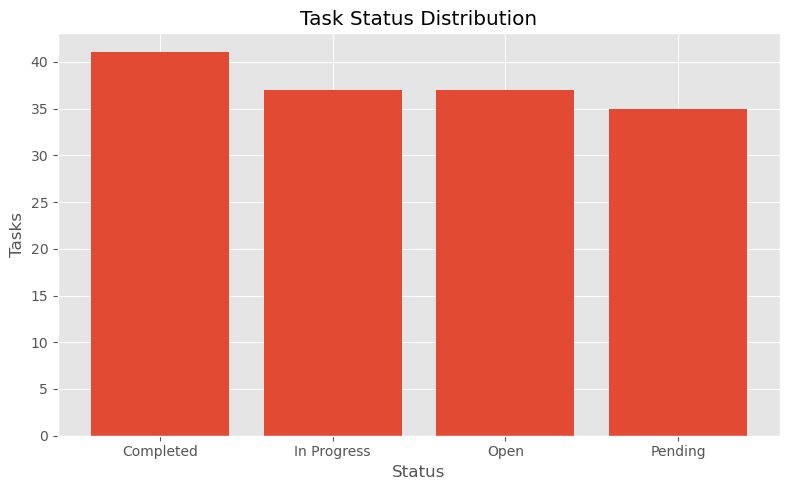

In [11]:
status=task_df["Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(status.index,status.values)

plt.title("Task Status Distribution")

plt.xlabel("Status")

plt.ylabel("Tasks")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Task_Status.png"))

plt.show()

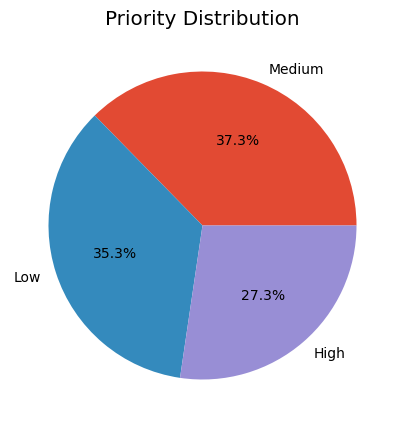

In [12]:
priority=task_df["Priority"].value_counts()

plt.figure(figsize=(8,5))

plt.pie(priority.values,
        labels=priority.index,
        autopct="%1.1f%%")

plt.title("Priority Distribution")

plt.savefig(os.path.join(charts_folder,"Priority_Distribution.png"))

plt.show()

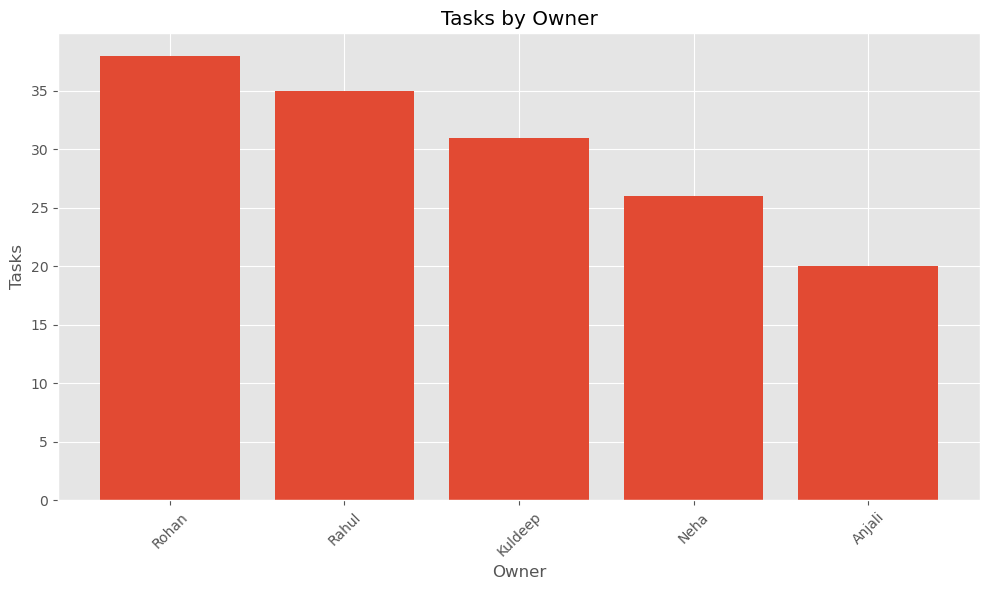

In [13]:
owner=task_df["Owner"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(owner.index,owner.values)

plt.title("Tasks by Owner")

plt.xlabel("Owner")

plt.ylabel("Tasks")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Owner_Workload.png"))

plt.show()

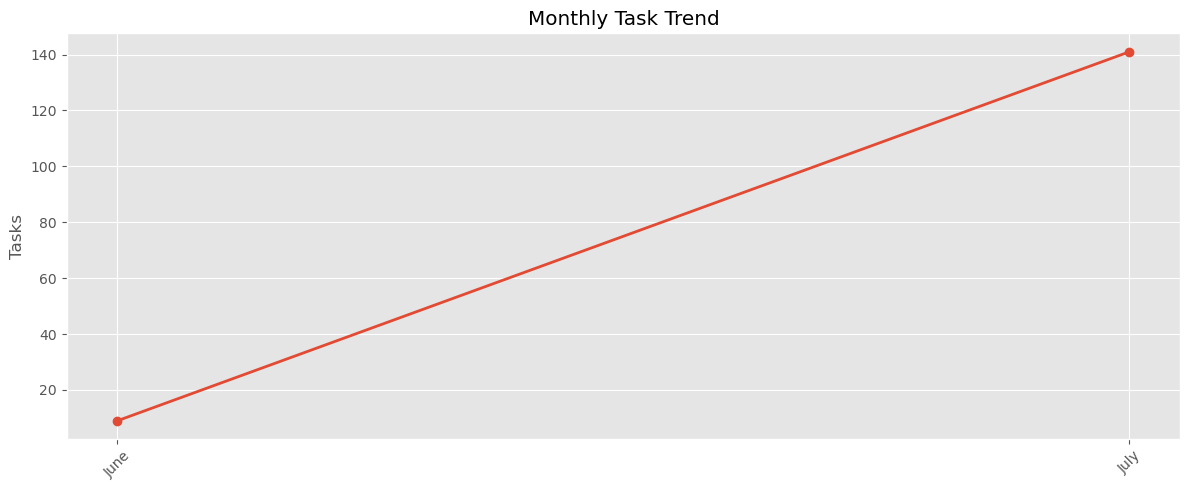

In [14]:
monthly=task_df.groupby("Month").size()

month_order=[
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]

monthly=monthly.reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(monthly.index,
         monthly.values,
         marker="o",
         linewidth=2)

plt.xticks(rotation=45)

plt.title("Monthly Task Trend")

plt.ylabel("Tasks")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Monthly_Task_Trend.png"))

plt.show()

In [15]:
top_owner=task_df["Owner"].value_counts().head(10)

print(top_owner)

Owner
Rohan      38
Rahul      35
Kuldeep    31
Neha       26
Anjali     20
Name: count, dtype: int64


In [16]:
summary=pd.DataFrame({

"Metric":[

"Total Tasks",

"Completed",

"Open",

"Pending",

"In Progress",

"Overdue",

"High Priority",

"Completion Rate"

],

"Value":[

total_tasks,

completed,

open_tasks,

pending,

progress,

overdue,

high_priority,

completion_rate

]

})

summary.to_excel(

os.path.join(

reports_folder,

"Task_Summary.xlsx"

),

index=False

)

print("Task Summary Saved Successfully")

Task Summary Saved Successfully


In [18]:
print("=" * 60)

print("TASK DASHBOARD COMPLETED")

print("=" * 60)

print(f"Charts Saved  : {charts_folder}")

print(f"Reports Saved : {reports_folder}")

print("=" * 60)

TASK DASHBOARD COMPLETED
Charts Saved  : Executive_Assistant_Business_Dashboard\charts
Reports Saved : Executive_Assistant_Business_Dashboard\reports
